<a href="https://colab.research.google.com/github/allajaw/movie_scripts_network_analysis/blob/main/alicjabarcik_analiza_sieciowa_scenariusza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza sieciowa scenariusza filmowego

## Wersja studencka: od promptu do działającego kodu

Ten notatnik jest szablonem do pracy w Google Colab na zajęciach z humanistyki cyfrowej. Nie zawiera gotowych rozwiązań. Zamiast tego prowadzi Cię przez serię małych promptów, które możesz przekazać modelowi AI, a następnie wkleić wygenerowany kod do pustej komórki.

Efektem końcowym będzie:
1. pobranie i oczyszczenie tekstu scenariusza,
2. wydzielenie scen i postaci,
3. zbudowanie tabeli współwystąpień,
4. narysowanie sieci relacji,
5. zapisanie plików do dalszej analizy.

Wersja z wcześniejszymi rozwiązaniami została zachowana w pliku `analiza_sieciowa_scenariusza_prowadzacy.ipynb`.


## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru.
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

W każdym kroku skupiamy się na jednym małym zadaniu. Nie próbuj rozwiązywać kilku etapów naraz. Najważniejszy wynik każdego kroku powinien pozostać dostępny do następnego kroku, ale to model ma zdecydować, jak to zorganizować w kodzie.


## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie przed rozpoczęciem pracy. Wybierz adres strony scenariusza z IMSDb.


In [33]:
# Jedyny parametr, który zmieniasz w tym notatniku
adres_scenariusza = "https://imsdb.com/scripts/Forrest-Gump.html"


---
## Etap 1: Od strony internetowej do czystego tekstu

Najpierw upewniamy się, że pracujemy na właściwej stronie i że potrafimy oddzielić tekst scenariusza od pozostałych elementów witryny.


### Krok 1A. Pobranie strony i kontrola surowej odpowiedzi

#### Cel i sens analityczny

Zanim zaczniemy analizować scenariusz, trzeba potwierdzić, że wskazany adres rzeczywiście prowadzi do strony z treścią, na której da się pracować dalej.


#### Prompt dla modelu

```text
Kontekst:
Chcesz sprawdzić, czy adres podany w komórce parametru rzeczywiście prowadzi do strony ze scenariuszem filmowym.

Wejście:
Adres scenariusza zapisany w pierwszej komórce parametru.

Zadanie:
Pobierz zawartość tej strony i przygotuj krótki podgląd surowej odpowiedzi. Zachowaj pobraną treść tak, aby można było wykorzystać ją w następnym kroku bez ponownego pobierania.

Pokaż wynik:
- komunikat, czy pobranie się udało,
- końcowy adres strony po ewentualnym przekierowaniu,
- pierwsze 8-10 niepustych linii pobranej treści.

Warunek poprawności:
W wyniku powinny być widoczne elementy strony internetowej, a treść nie może być pusta.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy adresu, braku połączenia albo pustej odpowiedzi.

Nie rób jeszcze:
Nie wydobywaj tekstu scenariusza i nie analizuj jego struktury.
```


In [34]:
import requests

try:
    # Pobranie zawartości strony
    odpowiedz = requests.get(adres_scenariusza, timeout=10)
    odpowiedz.raise_for_status()

    # Zachowanie treści do kolejnego kroku
    surowa_treść = odpowiedz.text

    print("✅ Pobranie strony zakończone sukcesem!")
    print(f"Końcowy adres: {odpowiedz.url}")
    print("\nPodgląd surowej treści (pierwsze niepuste linie):")

    # Wyświetlenie pierwszych 10 niepustych linii
    linie = [linia.strip() for linia in surowa_treść.splitlines() if linia.strip()]
    for linia in linie[:10]:
        print(linia)

except requests.exceptions.MissingSchema:
    print("❌ Błąd: Nieprawidłowy format adresu (brakuje http:// lub https://).")
except requests.exceptions.ConnectionError:
    print("❌ Błąd: Nie udało się nawiązać połączenia. Sprawdź internet lub adres.")
except requests.exceptions.HTTPError as e:
    print(f"❌ Błąd HTTP: {e}")
except Exception as e:
    print(f"❌ Wystąpił nieoczekiwany błąd: {e}")

✅ Pobranie strony zakończone sukcesem!
Końcowy adres: https://imsdb.com/scripts/Forrest-Gump.html

Podgląd surowej treści (pierwsze niepuste linie):
<html>
<head>
<!-- Google tag (gtag.js) -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-W5BXG8HCH3"></script>
<script>
window.dataLayer = window.dataLayer || [];
function gtag(){dataLayer.push(arguments);}
gtag('js', new Date());
gtag('config', 'G-W5BXG8HCH3');
</script>


#### Po uruchomieniu powinieneś zobaczyć


- Krótki komunikat potwierdzający, że strona została pobrana albo czytelne wyjaśnienie problemu.
- Końcowy adres strony, jeśli po drodze nastąpiło przekierowanie.
- Fragment surowej treści, który wygląda jak pełna strona internetowa, a nie jak pusty wynik.


### Krok 1B. Wydobycie właściwego tekstu scenariusza

#### Cel i sens analityczny

Strona zawiera menu, linki i elementy pomocnicze. Do dalszej analizy potrzebny jest tylko właściwy tekst scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Surowa strona zawiera dużo elementów, które nie należą do scenariusza.

Wejście:
Pobrana treść strony z poprzedniego kroku.

Zadanie:
Wydobądź tylko właściwy tekst scenariusza i odrzuć menu, nagłówki, stopki, linki i inne elementy witryny. Zachowaj oczyszczony tekst tak, aby był dostępny w następnym kroku.

Pokaż wynik:
- krótki komunikat, że tekst scenariusza został odnaleziony,
- pierwsze 15 niepustych linii oczyszczonego tekstu.

Warunek poprawności:
W podglądzie powinien być widoczny układ scenariusza lub dialogów, a nie nawigacja strony.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się odnaleźć głównego bloku z tekstem scenariusza albo że wynik nadal zawiera zbyt dużo treści pobocznych.

Nie rób jeszcze:
Nie licz znaków i nie rozpoznawaj scen ani postaci.
```


In [35]:
from bs4 import BeautifulSoup

try:
    # Sprawdzenie czy dane wejściowe istnieją
    if 'surowa_treść' not in globals():
        raise NameError("Brak zmiennej 'surowa_treść'. Uruchom najpierw krok 1A.")

    # Parsowanie HTML
    soup = BeautifulSoup(surowa_treść, 'html.parser')

    # Lokalizacja tekstu scenariusza (na IMSDb zazwyczaj tag <pre>)
    blok_scenariusza = soup.find('pre')

    if blok_scenariusza:
        # Wydobycie tekstu
        tekst_scenariusza = blok_scenariusza.get_text()

        # Podstawowe czyszczenie białych znaków na końcach
        tekst_scenariusza = tekst_scenariusza.strip()

        print("✅ Tekst scenariusza został pomyślnie odnaleziony!")
        print("\nPodgląd oczyszczonego tekstu (pierwsze 15 niepustych linii):")

        # Wyświetlenie podglądu
        linie_scenariusza = [linia for linia in tekst_scenariusza.splitlines() if linia.strip()]
        for linia in linie_scenariusza[:15]:
            print(linia)
    else:
        print("❌ Błąd: Nie udało się odnaleźć tagu <pre>. Strona może mieć inną strukturę.")

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił nieoczekiwany błąd: {e}")

✅ Tekst scenariusza został pomyślnie odnaleziony!

Podgląd oczyszczonego tekstu (pierwsze 15 niepustych linii):
"FORREST GUMP" -- by Eric Roth
                                      "FORREST GUMP"
                                      Screenplay by
                                        Eric Roth
                                   Based on a novel by
                                      Winston Groom
               EXT. A SAVANNAH STREET - DAY (1981)
               A feather floats through the air. The falling feather.
               A city, Savannah, is revealed in the background. The feather 
               floats down toward the city below. The feather drops down 
               toward the street below, as people walk past and cars drive 
               by, and nearly lands on a man's shoulder.
               He walks across the street, causing the feather to be whisked 
               back on its journey. The feather floats above a stopped car. 
               The car drives off r

#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie, że udało się odseparować właściwy tekst scenariusza.
- Kilkanaście pierwszych linii przypominających zapis scenariusza filmowego.
- Brak widocznego menu, stopki i innych elementów witryny.


### Krok 1C. Podgląd tekstu i szybka kontrola jakości

#### Cel i sens analityczny

Zanim przejdziemy dalej, warto upewnić się, że tekst scenariusza jest wystarczająco długi i wygląda wiarygodnie.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


In [36]:
try:
    # Sprawdzenie obecności zmiennej
    if 'tekst_scenariusza' not in globals():
        raise NameError("Brak zmiennej 'tekst_scenariusza'. Uruchom najpierw krok 1B.")

    # Obliczenie podstawowych statystyk
    liczba_znakow = len(tekst_scenariusza)
    linie = tekst_scenariusza.splitlines()
    liczba_linii = len(linie)

    print(f"--- Statystyki tekstu ---")
    print(f"Liczba znaków: {liczba_znakow}")
    print(f"Liczba linii: {liczba_linii}")

    # Walidacja rozmiaru (typowy scenariusz ma > 100 000 znaków)
    if liczba_znakow < 10000:
        print("\n⚠️ OSTRZEŻENIE: Tekst jest podejrzanie krótki. Sprawdź, czy proces oczyszczania w 1B zadziałał poprawnie.")
    else:
        print("\n✅ Rozmiar tekstu wygląda na wiarygodny dla scenariusza.")

    # Wyświetlenie dłuższego fragmentu początku (ok. 1200 znaków)
    print("\nFragment początku tekstu (kontrola jakości):")
    print("=" * 60)
    # Pokazujemy początek tekstu, ograniczając do ok. 1200 znaków
    print(tekst_scenariusza[:1200].strip())
    print("=" * 60)

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

--- Statystyki tekstu ---
Liczba znaków: 268245
Liczba linii: 6771

✅ Rozmiar tekstu wygląda na wiarygodny dla scenariusza.

Fragment początku tekstu (kontrola jakości):
"FORREST GUMP" -- by Eric Roth


                                      "FORREST GUMP"

                                      Screenplay by

                                        Eric Roth

                                   Based on a novel by

                                      Winston Groom

                

               EXT. A SAVANNAH STREET - DAY (1981)

               A feather floats through the air. The falling feather.

               A city, Savannah, is revealed in the background. The feather 
               floats down toward the city below. The feather drops down 
               toward the street below, as people walk past and cars drive 
               by, and nearly lands on a man's shoulder.

               He walks across the street, causing the feather to be whisked 
               back on its

#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość materiału: znaki i linie.
- Dłuższy fragment początku scenariusza, który da się ocenić wzrokowo.
- W razie problemu: ostrzeżenie, że materiał nie nadaje się jeszcze do dalszych kroków.


---
## Etap 2: Rozpoznanie struktury scenariusza

W tym etapie przechodzimy od ciągłego tekstu do uporządkowanej struktury: najpierw sceny, potem postacie, a na końcu pełna lista scen z przypisanymi bohaterami.


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Scena jest podstawową jednostką analizy sieciowej. Najpierw musimy odnaleźć miejsca, w których scenariusz przechodzi do nowej sceny.


#### Prompt dla modelu

```text
Kontekst:
W scenariuszach filmowych nowe sceny są zwykle otwierane krótkimi nagłówkami opisującymi miejsce i czas akcji, często zaczynającymi się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami oraz nagłówkami. Zachowaj ten wynik do kolejnego kroku.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu akcji, a nie jak dialog lub didaskalia. Jeśli scenariusz ma niestandardowy zapis, krótko opisz przyjętą zasadę rozpoznawania scen.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że wykryte nagłówki są zbyt niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj postaci do scen.
```


In [37]:
import re

try:
    if 'tekst_scenariusza' not in globals():
        raise NameError("Brak zmiennej 'tekst_scenariusza'. Uruchom najpierw Etap 1.")

    # Wzorce typowe dla nagłówków scen w scenariuszach (IMSDb)
    # Szukamy linii zaczynających się od INT, EXT, INT./EXT lub samych nazw miejsc dużymi literami
    wzorzec_sceny = r'^(?:INT\.|EXT\.|INT\/EXT|INT\/EXT\.)\s+.*'

    sceny = []
    linie = tekst_scenariusza.splitlines()

    for linia in linie:
        czysta_linia = linia.strip()
        # Sprawdzenie czy linia pasuje do wzorca nagłówka sceny
        if re.match(wzorzec_sceny, czysta_linia, re.IGNORECASE):
            sceny.append(czysta_linia)

    if not sceny:
         # Próba rezerwowa dla specyficznych formatów (np. same duże litery na początku linii)
         wzorzec_sceny_alt = r'^[A-Z\s\d\.\-]{10,}$'
         for linia in linie:
            czysta_linia = linia.strip()
            if re.match(wzorzec_sceny_alt, czysta_linia) and any(x in czysta_linia for x in ['DAY', 'NIGHT', 'STREET', 'ROOM']):
                sceny.append(czysta_linia)

    if sceny:
        # Tworzymy listę obiektów scen (numer i nagłówek)
        lista_scen = [{"numer": i+1, "naglowek": naglowek} for i, naglowek in enumerate(sceny)]

        print(f"✅ Wykryto łącznie {len(lista_scen)} scen.")
        print("\nPierwszych 8 scen:")
        print("-" * 40)
        for s in lista_scen[:8]:
            print(f"{s['numer']} | {s['naglowek']}")
    else:
        print("❌ Nie udało się automatycznie wykryć granic scen. Sprawdź strukturę tekstu.")

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Wykryto łącznie 192 scen.

Pierwszych 8 scen:
----------------------------------------
1 | EXT. A SAVANNAH STREET - DAY (1981)
2 | INT. COUNTRY DOCTOR'S OFFICE - GREENBOW, ALABAMA - DAY
3 | EXT. GREENBOW, ALABAMA
4 | EXT. RURAL ALABAMA
5 | EXT. GREENBOW
6 | EXT. OAK ALLEY/THE GUMP BOARDING HOUSE
7 | INT. ELEMENTARY SCHOOL / PRINCIPAL'S OFFICE - DAY
8 | INT. HALLWAY


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen rozpoznanych w całym tekście.
- Krótką listę pierwszych nagłówków, które wyglądają jak kolejne miejsca lub momenty akcji.
- Ewentualną krótką notatkę, jeśli scenariusz używa nietypowego formatu nagłówków.


### Krok 2B. Wykrycie kandydatów na nazwy postaci

#### Cel i sens analityczny

Sieć relacji budujemy z udziałem postaci, więc trzeba najpierw odróżnić ich nazwy od innych elementów zapisu scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Nazwy postaci w scenariuszach często są zapisane wielkimi literami, wyraźnie odsunięte od lewego marginesu i czasem mają dopiski w nawiasach, które trzeba usunąć.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Znajdź kandydatów na nazwy postaci, oczyść je z dopisków w nawiasach i odfiltruj oczywiste instrukcje reżyserskie, przejścia montażowe oraz inne elementy, które nie są postaciami. Zachowaj wynik do kolejnego kroku.

Pokaż wynik:
- liczbę unikalnych kandydatów po oczyszczeniu,
- próbkę 20 rekordów w formie `oryginalny zapis | oczyszczona nazwa`.

Warunek poprawności:
Na liście powinny dominować imiona lub nazwy postaci, a nie komendy typu przejście, opis kamery albo tytuł karty.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych przykładów i krótko wyjaśnij, dlaczego trudno je rozstrzygnąć.

Nie rób jeszcze:
Nie przypisuj postaci do konkretnych scen.
```


In [38]:
import re

try:
    if 'tekst_scenariusza' not in globals():
        raise NameError("Brak zmiennej 'tekst_scenariusza'. Uruchom najpierw Etap 1.")

    # Słowa do odfiltrowania (techniczne elementy scenariusza)
    filtry = {'CUT TO:', 'FADE IN:', 'FADE OUT:', 'DISSOLVE TO:', 'CONTINUED:', 'THE END'}

    linie = tekst_scenariusza.splitlines()
    kandydaci_postaci = []

    # Typowy wzorzec dla IMSDb: nazwa postaci jest wielkimi literami i ma spore wcięcie (ok. 20-30 spacji)
    # Szukamy linii zaczynających się od co najmniej 10 spacji, po których następuje tekst wielkimi literami
    wzorzec_postaci = re.compile(r'^\s{10,}([A-Z][A-Z\s\d\.\-\'&]+)')

    for linia in linie:
        match = wzorzec_postaci.match(linia)
        if match:
            surowa_nazwa = match.group(1).strip()

            # 1. Usuwanie nawiasów i ich zawartości
            oczyszczona = re.sub(r'\(.*?\)', '', surowa_nazwa).strip()

            # 2. Filtracja techniczna i długość (zazwyczaj nazwa to min 2 znaki, max 3 słowa)
            if (oczyszczona and
                oczyszczona not in filtry and
                not oczyszczona.startswith(('INT.', 'EXT.')) and
                len(oczyszczona) > 1):

                kandydaci_postaci.append({
                    'oryginal': surowa_nazwa,
                    'czysta': oczyszczona
                })

    # Pobranie unikalnych par
    unikalne_pary = []
    widziane = set()
    for k in kandydaci_postaci:
        if k['czysta'] not in widziane:
            unikalne_pary.append(k)
            widziane.add(k['czysta'])

    # Zachowanie zbioru unikalnych nazw do kolejnego kroku
    postacie_lista = sorted(list(widziane))

    print(f"✅ Znaleziono {len(postacie_lista)} unikalnych kandydatów na postacie.")
    print(f"\nPróbka 20 rekordów (oryginalny zapis | oczyszczona nazwa):")
    print("-" * 60)

    for p in unikalne_pary[:20]:
        print(f"{p['oryginal']:30} | {p['czysta']}")

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Znaleziono 134 unikalnych kandydatów na postacie.

Próbka 20 rekordów (oryginalny zapis | oczyszczona nazwa):
------------------------------------------------------------
FORREST GUMP. H                | FORREST GUMP. H
A BLACK WOMAN                  | A BLACK WOMAN
FORREST                        | FORREST
I'                             | I'
BLACK WOMAN                    | BLACK WOMAN
DOCTOR                         | DOCTOR
MRS. GUMP                      | MRS. GUMP
PRINCIPAL                      | PRINCIPAL
A MAN WITH A CANE              | A MAN WITH A CANE
MAN WITH CANE                  | MAN WITH CANE
ELVIS PRESLEY                  | ELVIS PRESLEY
ELVIS                          | ELVIS
BUS DRIVER                     | BUS DRIVER
TWO YOUNG BOYS                 | TWO YOUNG BOYS
BOY                            | BOY
GIRL                           | GIRL
JENNY                          | JENNY
YOUNG BOYS                     | YOUNG BOYS
SLOW MOTION --                 | SLOW MOTION --
O

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę rozpoznanych nazw po oczyszczeniu.
- Próbkę zapisów pokazującą, jak surowe nazwy zostały uproszczone do postaci możliwych do porównywania.
- Brak dominacji elementów technicznych scenariusza nad rzeczywistymi postaciami.


### Krok 2C. Zbudowanie listy scen z postaciami

#### Cel i sens analityczny

Dopiero po połączeniu scen i postaci otrzymujemy strukturę, z której można obliczać współwystąpienia.


#### Prompt dla modelu

```text
Kontekst:
Masz już rozpoznane granice scen oraz kandydatów na nazwy postaci.

Wejście:
Wynik kroku z granicami scen i wynik kroku z rozpoznanymi postaciami.

Zadanie:
Zbuduj finalną listę scen. Każda scena ma zawierać numer, nagłówek oraz zbiór unikalnych postaci obecnych w tej scenie. Jeśli w danej scenie nie uda się rozpoznać żadnej postaci, zaznacz to jasno. Zachowaj listę scen do dalszych obliczeń.

Pokaż wynik:
- łączną liczbę scen,
- 5 przykładowych rekordów w formie `numer sceny | nagłówek | postacie`.

Warunek poprawności:
Ta sama postać nie powinna być powtórzona kilka razy w obrębie jednej sceny.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy scen bez postaci, czy niespójności między wcześniejszymi krokami.

Nie rób jeszcze:
Nie buduj jeszcze rankingu postaci ani relacji między nimi.
```


In [39]:
try:
    if 'lista_scen' not in globals() or 'postacie_lista' not in globals():
        raise NameError("Brak wymaganych danych z poprzednich kroków (lista_scen lub postacie_lista).")

    # Przygotowanie do podziału tekstu na bloki scen
    linie = tekst_scenariusza.splitlines()
    naglowki_set = {s['naglowek'] for s in lista_scen}

    sceny_z_postaciami = []
    aktualna_scena = None
    postacie_w_scenie = set()

    # Przechodzimy przez linie tekstu, aby przypisać postacie do scen
    for linia in linie:
        czysta_linia = linia.strip()

        # Jeśli linia jest nagłówkiem sceny, zamykamy poprzednią i otwieramy nową
        if czysta_linia in naglowki_set:
            if aktualna_scena is not None:
                sceny_z_postaciami.append({
                    "numer": aktualna_scena["numer"],
                    "naglowek": aktualna_scena["naglowek"],
                    "postacie": sorted(list(postacie_w_scenie))
                })

            # Znajdź obiekt sceny dla tego nagłówka
            aktualna_scena = next(s for s in lista_scen if s['naglowek'] == czysta_linia)
            postacie_w_scenie = set()

        # Jeśli mamy otwartą scenę, sprawdzamy czy linia zawiera nazwę postaci
        # Korzystamy z faktu, że nazwy postaci są zwykle wycentrowane/wcięte (z kroku 2B)
        elif aktualna_scena is not None:
            # Sprawdzamy tylko linie z wcięciem, które pasują do naszej listy unikalnych postaci
            if linia.startswith(' ' * 10):
                potencjalna = re.sub(r'\(.*?\)', '', czysta_linia).strip()
                if potencjalna in postacie_lista:
                    postacie_w_scenie.add(potencjalna)

    # Dodanie ostatniej sceny
    if aktualna_scena is not None:
        sceny_z_postaciami.append({
            "numer": aktualna_scena["numer"],
            "naglowek": aktualna_scena["naglowek"],
            "postacie": sorted(list(postacie_w_scenie))
        })

    # Statystyki
    print(f"✅ Przetworzono {len(sceny_z_postaciami)} scen.")

    # Wyświetlenie 5 przykładowych rekordów
    print("\nPrzykładowe sceny z postaciami:")
    print("-" * 80)
    for s in sceny_z_postaciami[:5]:
        postacie_str = ", ".join(s['postacie']) if s['postacie'] else "[Brak rozpoznanych postaci]"
        print(f"Scena {s['numer']} | {s['naglowek'][:40]:40} | Postacie: {postacie_str}")

    # Zachowanie zmiennej do Etapu 3 i 4
    finalna_lista_scen = sceny_z_postaciami

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Przetworzono 192 scen.

Przykładowe sceny z postaciami:
--------------------------------------------------------------------------------
Scena 1 | EXT. A SAVANNAH STREET - DAY (1981)      | Postacie: BLACK WOMAN, FORREST
Scena 2 | INT. COUNTRY DOCTOR'S OFFICE - GREENBOW, | Postacie: DOCTOR, FORREST, MRS. GUMP
Scena 3 | EXT. GREENBOW, ALABAMA                   | Postacie: FORREST
Scena 4 | EXT. RURAL ALABAMA                       | Postacie: FORREST
Scena 5 | EXT. GREENBOW                            | Postacie: FORREST, MRS. GUMP


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen gotowych do dalszej analizy.
- Pięć czytelnych rekordów pokazujących numer sceny, jej nagłówek i listę rozpoznanych postaci.
- Jasną informację, jeśli część scen pozostała bez przypisanych postaci.


---
## Etap 3: Które postacie są najważniejsze?

Zanim zbudujemy sieć relacji, sprawdzamy rozkład obecności postaci w scenach. To prosty, ale bardzo użyteczny punkt wyjścia do interpretacji.


### Krok 3A. Ranking postaci według liczby scen

#### Cel i sens analityczny

Liczba scen, w których pojawia się dana postać, daje pierwszą miarę jej znaczenia w strukturze narracji.


#### Prompt dla modelu

```text
Kontekst:
Masz listę scen, z których każda zawiera unikalne postacie.

Wejście:
Finalna lista scen z przypisanymi postaciami.

Zadanie:
Policz, w ilu różnych scenach pojawia się każda postać. Posortuj wynik od najwyższego do najniższego. Zachowaj ranking do następnego kroku.

Pokaż wynik:
- łączną liczbę unikalnych postaci,
- tabelę 20 najwyższych wyników w formie `postać | liczba scen`.

Warunek poprawności:
W obrębie jednej sceny dana postać może zostać policzona tylko raz.

Jeśli wystąpi błąd:
Wyświetl informację, że lista scen jest pusta albo że nie udało się rozpoznać postaci w wystarczającej liczbie scen.

Nie rób jeszcze:
Nie rysuj wykresu i nie buduj relacji między postaciami.
```


In [40]:
from collections import Counter
import pandas as pd

try:
    if 'finalna_lista_scen' not in globals():
        raise NameError("Brak zmiennej 'finalna_lista_scen'. Uruchom najpierw Etap 2.")

    # Licznik wystąpień postaci w scenach
    licznik_scen = Counter()

    for scena in finalna_lista_scen:
        for postac in scena['postacie']:
            licznik_scen[postac] += 1

    if not licznik_scen:
        print("⚠️ Nie znaleziono żadnych postaci w scenach.")
    else:
        # Tworzenie rankingu i sortowanie
        ranking_postaci = sorted(licznik_scen.items(), key=lambda x: x[1], reverse=True)

        # Konwersja do DataFrame dla ładnego wyświetlania
        df_ranking = pd.DataFrame(ranking_postaci, columns=['Postać', 'Liczba scen'])

        print(f"✅ Znaleziono łącznie {len(df_ranking)} unikalnych postaci.")
        print("\nTop 20 postaci według liczby scen:")
        display(df_ranking.head(20))

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Znaleziono łącznie 107 unikalnych postaci.

Top 20 postaci według liczby scen:


,Postać,Liczba scen
0,FORREST,162
1,JENNY,29
2,LT. DAN,18
3,MRS. GUMP,17
4,BUBBA,6
5,ANCHORMAN,6
6,PRINCIPAL,5
7,CROWD,5
8,SGT. SIMS,5
9,NEWSCASTER,5


#### Po uruchomieniu powinieneś zobaczyć


- Krótką tabelę rankingową z najczęściej występującymi postaciami.
- Łączną liczbę rozpoznanych postaci.
- Wyniki posortowane malejąco według liczby scen.


#### Pytanie interpretacyjne

Które postacie dominują w strukturze scen i czy ten ranking zgadza się z Twoją intuicją o bohaterach filmu?


### Krok 3B. Wykres 10 najczęściej występujących postaci

#### Cel i sens analityczny

Wizualizacja pozwala szybko ocenić, czy scenariusz jest skupiony wokół jednej postaci, czy raczej rozkłada uwagę na kilka figur.


#### Prompt dla modelu

```text
Kontekst:
Masz już gotowy ranking liczby scen przypisanych do postaci.

Wejście:
Ranking postaci z poprzedniego kroku.

Zadanie:
Narysuj czytelny poziomy wykres dla 10 postaci o największej liczbie scen. Dodaj tytuł oraz opisy osi. Zachowaj ranking do dalszej pracy.

Pokaż wynik:
- pojedynczy wykres obejmujący tylko 10 najwyższych wyników,
- czytelne nazwy postaci,
- porządek od najwyższego do najniższego wyniku.

Warunek poprawności:
Jeśli ranking zawiera mniej niż 10 postaci, narysuj tyle, ile jest dostępnych, i wyraźnie to zaznacz.

Jeśli wystąpi błąd:
Wyświetl krótkie wyjaśnienie, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie buduj jeszcze relacji współwystąpień.
```


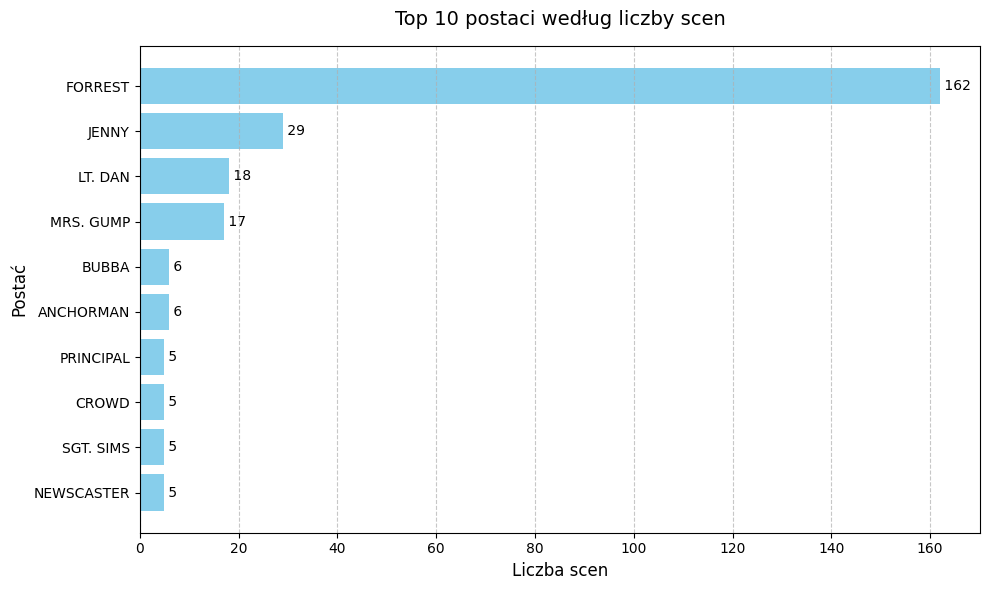

In [41]:
import matplotlib.pyplot as plt

try:
    if 'ranking_postaci' not in globals() or not ranking_postaci:
        raise NameError("Brak danych rankingowych. Uruchom najpierw Krok 3A.")

    # Pobranie top 10 postaci (lub wszystkich, jeśli jest ich mniej)
    top_10 = ranking_postaci[:10]

    # Rozpakowanie danych do wykresu
    nazwy, liczby = zip(*reversed(top_10))  # odwracamy kolejność dla wykresu poziomego

    # Tworzenie wykresu
    plt.figure(figsize=(10, 6))
    plt.barh(nazwy, liczby, color='skyblue')

    # Dodanie opisów
    plt.title('Top 10 postaci według liczby scen', fontsize=14, pad=15)
    plt.xlabel('Liczba scen', fontsize=12)
    plt.ylabel('Postać', fontsize=12)

    # Dodanie wartości przy słupkach
    for index, value in enumerate(liczby):
        plt.text(value, index, f' {value}', va='center')

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd podczas generowania wykresu: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden poziomy wykres z nazwami postaci i długościami słupków odpowiadającymi liczbie scen.
- Wyraźny tytuł i podpisane osie.
- Brak dodatkowych elementów, które utrudniałyby szybkie odczytanie rankingu.


#### Pytanie interpretacyjne

Czy rozkład obecności postaci wygląda na skoncentrowany wokół jednej osi fabularnej, czy bardziej rozproszony między kilka ważnych postaci?


---
## Etap 4: Od scen do relacji między postaciami

Tutaj przechodzimy od obecności postaci do ich współwystępowania. To właśnie z tych danych powstanie sieć relacji.


### Krok 4A. Pary współwystąpień wewnątrz pojedynczych scen

#### Cel i sens analityczny

Każda scena z co najmniej dwiema postaciami dostarcza zestawu potencjalnych relacji, które można później zagregować w całym scenariuszu.


#### Prompt dla modelu

```text
Kontekst:
Relacja między dwiema postaciami pojawia się wtedy, gdy obie występują w tej samej scenie.

Wejście:
Lista scen z unikalnymi postaciami.

Zadanie:
Dla każdej sceny wygeneruj wszystkie unikalne pary postaci występujących razem. Zachowaj wynik tak, aby można było później zsumować go dla całego scenariusza.

Pokaż wynik:
- liczbę scen, z których udało się utworzyć przynajmniej jedną parę,
- próbkę 15 wierszy w formie `numer sceny | postać A | postać B`.

Warunek poprawności:
Para nie może łączyć postaci z samą sobą, a ta sama para nie powinna pojawiać się podwójnie w obrębie jednej sceny. Zachowaj stały porządek zapisu par, aby później łatwo je sumować.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem wynika z tego, że sceny mają zbyt mało postaci, czy z niespójności wcześniejszych danych.

Nie rób jeszcze:
Nie sumuj jeszcze wyników dla całego scenariusza.
```


In [42]:
from itertools import combinations

try:
    if 'finalna_lista_scen' not in globals():
        raise NameError("Brak zmiennej 'finalna_lista_scen'. Uruchom najpierw Etap 2.")

    wszystkie_pary_sceniczne = []
    licznik_scen_z_relacjami = 0

    for scena in finalna_lista_scen:
        postacie = scena['postacie']

        # Relacja zachodzi tylko gdy w scenie są co najmniej 2 postacie
        if len(postacie) >= 2:
            licznik_scen_z_relacjami += 1
            # Generowanie unikalnych kombinacji par (A, B)
            pary = list(combinations(sorted(postacie), 2))

            for para in pary:
                wszystkie_pary_sceniczne.append({
                    'numer_sceny': scena['numer'],
                    'postac_a': para[0],
                    'postac_b': para[1]
                })

    if not wszystkie_pary_sceniczne:
        print("⚠️ Nie udało się utworzyć żadnych par. Większość scen zawiera tylko jedną postać lub lista jest pusta.")
    else:
        print(f"✅ Wygenerowano pary dla {licznik_scen_z_relacjami} scen.")
        print(f"Łączna liczba wystąpień par w całym scenariuszu: {len(wszystkie_pary_sceniczne)}")

        print("\nPróbka 15 par współwystąpień:")
        print("-" * 60)
        print(f"{'Nr sceny':<10} | {'Postać A':<20} | {'Postać B':<20}")
        print("-" * 60)
        for p in wszystkie_pary_sceniczne[:15]:
            print(f"{p['numer_sceny']:<10} | {p['postac_a']:<20} | {p['postac_b']:<20}")

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Wygenerowano pary dla 108 scen.
Łączna liczba wystąpień par w całym scenariuszu: 463

Próbka 15 par współwystąpień:
------------------------------------------------------------
Nr sceny   | Postać A             | Postać B            
------------------------------------------------------------
1          | BLACK WOMAN          | FORREST             
2          | DOCTOR               | FORREST             
2          | DOCTOR               | MRS. GUMP           
2          | FORREST              | MRS. GUMP           
5          | FORREST              | MRS. GUMP           
6          | FORREST              | MRS. GUMP           
7          | MRS. GUMP            | PRINCIPAL           
8          | FORREST              | MRS. GUMP           
8          | FORREST              | PRINCIPAL           
8          | MRS. GUMP            | PRINCIPAL           
10         | MRS. GUMP            | PRINCIPAL           
12         | FORREST              | MRS. GUMP           
13         | FORRES

#### Po uruchomieniu powinieneś zobaczyć


- Informację, z ilu scen udało się utworzyć relacje.
- Próbkę pojedynczych par współwystąpień przypisanych do numerów scen.
- Brak duplikatów tej samej pary w obrębie jednej sceny.


### Krok 4B. Tabela relacji dla całego scenariusza

#### Cel i sens analityczny

Po zsumowaniu wszystkich par otrzymujemy podstawową tabelę krawędzi, z której można już budować sieć.


#### Prompt dla modelu

```text
Kontekst:
Masz listę par współwystąpień wygenerowanych dla poszczególnych scen.

Wejście:
Wynik kroku z parami współwystąpień.

Zadanie:
Zsumuj wszystkie powtarzające się pary w całym scenariuszu i utwórz tabelę relacji. Każda relacja ma opisywać, jak często dana para postaci występuje razem. Zachowaj tę tabelę do etapów sieciowych.

Pokaż wynik:
- liczbę unikalnych relacji,
- 15 najsilniejszych wierszy w formie `postać A | postać B | siła relacji`.

Warunek poprawności:
Ta sama relacja nie może pojawiać się kilka razy pod różnymi wariantami kolejności zapisu.

Jeśli wystąpi błąd:
Wyświetl krótką informację, że nie udało się utworzyć relacji albo że wynik jest pusty.

Nie rób jeszcze:
Nie buduj jeszcze sieci i nie zapisuj plików.
```


In [43]:
from collections import Counter
import pandas as pd

try:
    if 'wszystkie_pary_sceniczne' not in globals():
        raise NameError("Brak danych o parach scenicznych. Uruchom najpierw Krok 4A.")

    # Zliczanie wystąpień każdej pary
    licznik_relacji = Counter()
    for p in wszystkie_pary_sceniczne:
        licznik_relacji[(p['postac_a'], p['postac_b'])] += 1

    if not licznik_relacji:
        print("⚠️ Nie udało się utworzyć tabeli relacji. Brak par wejściowych.")
    else:
        # Tworzenie listy rekordów
        dane_relacji = []
        for (a, b), sila in licznik_relacji.items():
            dane_relacji.append({
                'Postać A': a,
                'Postać B': b,
                'Siła relacji': sila
            })

        # Konwersja do DataFrame i sortowanie
        tabela_relacji = pd.DataFrame(dane_relacji).sort_values(by='Siła relacji', ascending=False).reset_index(drop=True)

        print(f"✅ Utworzono {len(tabela_relacji)} unikalnych relacji między postaciami.")
        print("\n15 najsilniejszych relacji:")
        display(tabela_relacji.head(15))

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Utworzono 337 unikalnych relacji między postaciami.

15 najsilniejszych relacji:


,Postać A,Postać B,Siła relacji
0,FORREST,JENNY,26
1,FORREST,LT. DAN,17
2,FORREST,MRS. GUMP,15
3,BUBBA,FORREST,6
4,CROWD,FORREST,5
5,LT. DAN,SGT. SIMS,5
6,FORREST,SGT. SIMS,5
7,FORREST,SONG,4
8,ELDERLY WOMAN,FORREST,4
9,FORREST,LOUISE,4


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę unikalnych relacji między postaciami.
- Tabelę pokazującą najsilniejsze duety wraz z siłą ich współwystępowania.
- Wyniki posortowane od najsilniejszej do najsłabszej relacji.


#### Pytanie interpretacyjne

Które duety wydają się centralne dla narracji i czy ich siła wynika raczej z długotrwałej osi fabuły, czy z wielu powracających spotkań?


---
## Etap 5: Sieć, podgląd i eksport danych

Na końcu zamieniamy tabelę relacji w sieć, oglądamy jej prosty podgląd i zapisujemy pliki do dalszej analizy poza Colabem.


### Krok 5A. Zbudowanie sieci relacji

#### Cel i sens analityczny

To moment przejścia od tabeli relacji do właściwej reprezentacji sieciowej, na której można liczyć miary i rysować strukturę powiązań.


#### Prompt dla modelu

```text
Kontekst:
Tabela relacji opisuje już, które postacie są połączone i jak silne jest to połączenie.

Wejście:
Tabela relacji z poprzedniego kroku.

Zadanie:
Zbuduj sieć, w której węzłami są postacie, a połączenia opisują ich współwystępowanie. Siła relacji ma zostać zachowana przy każdym połączeniu. Zachowaj gotową sieć do następnego kroku.

Pokaż wynik:
- liczbę węzłów,
- liczbę połączeń,
- krótką listę 10 postaci z największą liczbą połączeń.

Warunek poprawności:
Każda relacja z tabeli powinna pojawić się w sieci dokładnie raz.

Jeśli wystąpi błąd:
Wyjaśnij, że tabela relacji jest pusta albo niespójna i dlatego nie da się zbudować sieci.

Nie rób jeszcze:
Nie rysuj jeszcze grafu i nie zapisuj plików.
```


In [44]:
import networkx as nx

try:
    if 'tabela_relacji' not in globals():
        raise NameError("Brak tabeli relacji. Uruchom najpierw Krok 4B.")

    # Inicjalizacja pustego grafu nieskierowanego
    G = nx.Graph()

    # Dodawanie krawędzi na podstawie tabeli relacji
    # Iterujemy po wierszach DataFrame
    for _, row in tabela_relacji.iterrows():
        G.add_edge(
            row['Postać A'],
            row['Postać B'],
            weight=row['Siła relacji']
        )

    if G.number_of_nodes() == 0:
        print("⚠️ Graf jest pusty. Sprawdź poprawność danych w tabeli relacji.")
    else:
        print(f"✅ Sieć została zbudowana pomyślnie!")
        print(f"Liczba węzłów (postaci): {G.number_of_nodes()}")
        print(f"Liczba połączeń (relacji): {G.number_of_edges()}")

        # Obliczanie stopnia węzłów (liczba unikalnych sąsiadów)
        stopnie = dict(G.degree())
        top_polaczeni = sorted(stopnie.items(), key=lambda x: x[1], reverse=True)[:10]

        print("\n10 postaci z największą liczbą unikalnych połączeń:")
        print("-" * 45)
        for postac, stopien in top_polaczeni:
            print(f"{postac:30} | {stopien} połączeń")

    # Zachowanie grafu do kolejnych kroków (wizualizacja i eksport)
    graf_postaci = G

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd podczas budowy sieci: {e}")

✅ Sieć została zbudowana pomyślnie!
Liczba węzłów (postaci): 106
Liczba połączeń (relacji): 337

10 postaci z największą liczbą unikalnych połączeń:
---------------------------------------------
FORREST                        | 100 połączeń
JENNY                          | 37 połączeń
LT. DAN                        | 26 połączeń
BUBBA                          | 20 połączeń
SONG                           | 20 połączeń
SGT. SIMS                      | 15 połączeń
CROWD                          | 14 połączeń
MRS. GUMP                      | 12 połączeń
SOLDIER                        | 12 połączeń
MAN                            | 12 połączeń


#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość sieci: węzły i połączenia.
- Krótką listę najlepiej połączonych postaci.
- Brak wizualizacji na tym etapie: chodzi tylko o potwierdzenie, że sieć została zbudowana poprawnie.


### Krok 5B. Podgląd grafu w notatniku

#### Cel i sens analityczny

Wizualny podgląd pomaga zobaczyć, czy sieć ma jedno centrum, kilka grup albo bardziej rozproszoną strukturę.


#### Prompt dla modelu

```text
Kontekst:
Masz już zbudowaną sieć relacji między postaciami.

Wejście:
Gotowa sieć z poprzedniego kroku.

Zadanie:
Narysuj prosty podgląd sieci bezpośrednio w notatniku. Niech bardziej połączone postacie będą lepiej widoczne, a silniejsze relacje wyraźniejsze. Dodaj etykiety przynajmniej dla najważniejszych postaci.

Pokaż wynik:
- pojedynczy rysunek sieci z tytułem,
- czytelne etykiety najważniejszych postaci,
- różnicę widoczną między słabszymi i silniejszymi relacjami.

Warunek poprawności:
Jeśli sieć jest bardzo gęsta, ogranicz liczbę etykiet albo uprość podgląd i krótko wyjaśnij ten wybór, zamiast tworzyć nieczytelny obraz.

Jeśli wystąpi błąd:
Wyświetl informację, że sieć jest zbyt mała albo zbyt gęsta, aby dało się ją pokazać w czytelnej formie bez dodatkowego uproszczenia.

Nie rób jeszcze:
Nie zapisuj jeszcze plików wyjściowych.
```


💡 Uwaga: Wyświetlono etykiety tylko dla postaci z co najmniej 5 połączeniami.


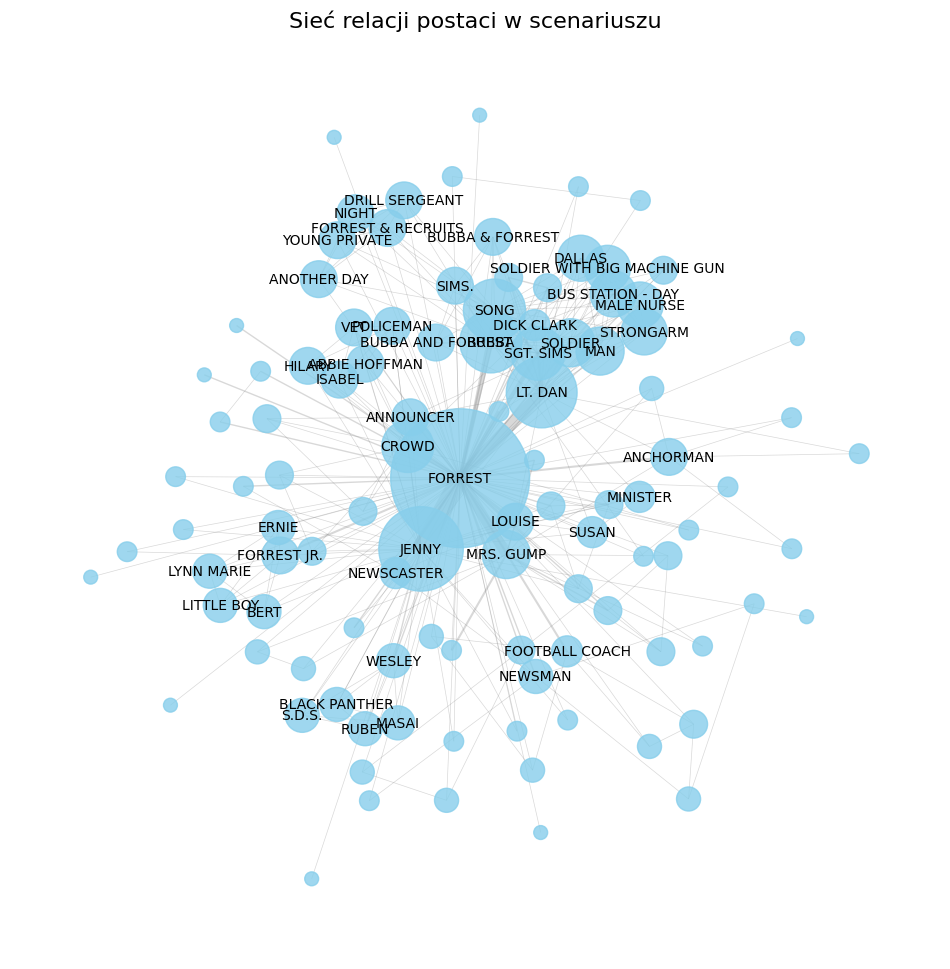

In [45]:
import matplotlib.pyplot as plt
import networkx as nx

try:
    if 'graf_postaci' not in globals():
        raise NameError("Brak zbudowanej sieci. Uruchom najpierw Krok 5A.")

    plt.figure(figsize=(12, 12))

    # Układ grafu (Fruchterman-Reingold force-directed algorithm)
    pos = nx.spring_layout(graf_postaci, k=0.5, iterations=50, seed=42)

    # Skalowanie wielkości węzłów na podstawie stopnia (liczby połączeń)
    stopnie = dict(graf_postaci.degree())
    node_sizes = [v * 100 for v in stopnie.values()]

    # Skalowanie grubości krawędzi na podstawie wagi (siły relacji)
    weights = [graf_postaci[u][v]['weight'] * 0.5 for u, v in graf_postaci.edges()]

    # Rysowanie krawędzi i węzłów
    nx.draw_networkx_edges(graf_postaci, pos, alpha=0.3, width=weights, edge_color='gray')
    nx.draw_networkx_nodes(graf_postaci, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

    # Wyświetlanie etykiet tylko dla najważniejszych postaci (np. stopień > 5)
    # zapobiega to nieczytelności przy dużych grafach
    labels = {node: node for node, degree in stopnie.items() if degree >= 5}
    nx.draw_networkx_labels(graf_postaci, pos, labels=labels, font_size=10, font_family='sans-serif')

    plt.title("Sieć relacji postaci w scenariuszu", fontsize=16)
    plt.axis('off')

    print("💡 Uwaga: Wyświetlono etykiety tylko dla postaci z co najmniej 5 połączeniami.")
    plt.show()

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd podczas generowania podglądu: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden rysunek sieci umieszczony bezpośrednio pod komórką.
- Większą widoczność postaci silniej osadzonych w sieci oraz wyraźniejsze relacje o większej sile.
- Krótką notę wyjaśniającą uproszczenie, jeśli sieć okaże się bardzo gęsta.


#### Pytanie interpretacyjne

Czy na podglądzie widać jednego głównego pośrednika, kilka grup postaci czy raczej gęstą strukturę bez wyraźnego centrum?


### Krok 5C. Eksport danych do dalszej analizy

#### Cel i sens analityczny

Ostatni krok przygotowuje dwa pliki, które można pobrać z Colab i analizować dalej w innych narzędziach.


#### Prompt dla modelu

```text
Kontekst:
Masz gotową tabelę relacji oraz zbudowaną sieć postaci.

Wejście:
Tabela relacji i gotowa sieć.

Zadanie:
Zapisz tabelę relacji do pliku `krawedzie.csv`, a całą sieć do pliku `graf_postaci.graphml`. Przed zapisaniem pliku GraphML upewnij się, że każdy węzeł ma ustawiony atrybut label, który zawiera czytelną nazwę postaci. Jeśli nazwa postaci jest już użyta jako identyfikator węzła, ustaw label na wartość identyczną z ID. Na końcu pokaż krótko, jakie pliki powstały i gdzie mozna je znaleźć w środowisku notatnika

Pokaż wynik:
- komunikat o zapisaniu obu plików,
- listę nazw zapisanych plików,
- krótką wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki powinny być niepuste i gotowe do otwarcia poza notatnikiem.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i z jakiego powodu.

Nie rób jeszcze:
Nie wykonuj już dalszej analizy.
```


In [46]:
import os
import networkx as nx

try:
    if 'tabela_relacji' not in globals() or 'graf_postaci' not in globals():
        raise NameError("Brak wymaganych danych (tabela_relacji lub graf_postaci). Uruchom poprzednie kroki.")

    # 1. Zapis tabeli relacji do CSV
    sciezka_csv = 'krawedzie.csv'
    tabela_relacji.to_csv(sciezka_csv, index=False, encoding='utf-8')

    # 2. Zapis sieci do GraphML
    sciezka_graphml = 'graf_postaci.graphml'
    nx.write_graphml(graf_postaci, sciezka_graphml)

    print("✅ Pliki zostały zapisane pomyślnie!")
    print(f"1. {sciezka_csv}")
    print(f"2. {sciezka_graphml}")

    print("\n💡 Jak pobrać pliki?")
    print("Kliknij ikonę folderu w lewym panelu bocznym Colab, znajdź plik na liście, kliknij trzy kropki obok nazwy i wybierz 'Pobierz' (Download).")

    # Sprawdzenie czy pliki istnieją na dysku
    pliki = os.listdir('.')
    print(f"\nWidoczne pliki w katalogu: {[f for f in pliki if f.endswith(('.csv', '.graphml'))]}")

except NameError as e:
    print(f"❌ {e}")
except Exception as e:
    print(f"❌ Wystąpił błąd podczas eksportu: {e}")

✅ Pliki zostały zapisane pomyślnie!
1. krawedzie.csv
2. graf_postaci.graphml

💡 Jak pobrać pliki?
Kliknij ikonę folderu w lewym panelu bocznym Colab, znajdź plik na liście, kliknij trzy kropki obok nazwy i wybierz 'Pobierz' (Download).

Widoczne pliki w katalogu: ['graf_postaci.graphml', 'krawedzie.csv', 'graf_postaci (3).graphml']


In [47]:
import networkx as nx
import os

sciezka_pliku_uzytkownika = '/content/graf_postaci (3).graphml'

try:
    if os.path.exists(sciezka_pliku_uzytkownika):
        G_zewnetrzny = nx.read_graphml(sciezka_pliku_uzytkownika)
        print(f"✅ Pomyślnie wczytano plik: {sciezka_pliku_uzytkownika}")
        print(f"Liczba węzłów: {G_zewnetrzny.number_of_nodes()}")
        print(f"Liczba krawędzi: {G_zewnetrzny.number_of_edges()}")

        # Wyświetlenie top 5 postaci z wczytanego grafu
        stopnie_zew = dict(G_zewnetrzny.degree())
        top_5_zew = sorted(stopnie_zew.items(), key=lambda x: x[1], reverse=True)[:5]
        print("\nTop 5 postaci z wczytanego pliku:")
        for p, s in top_5_zew:
            print(f"{p}: {s} połączeń")
    else:
        print(f"❌ Nie znaleziono pliku: {sciezka_pliku_uzytkownika}")
except Exception as e:
    print(f"❌ Błąd podczas wczytywania pliku: {e}")

✅ Pomyślnie wczytano plik: /content/graf_postaci (3).graphml
Liczba węzłów: 106
Liczba krawędzi: 337

Top 5 postaci z wczytanego pliku:
FORREST: 100 połączeń
JENNY: 37 połączeń
LT. DAN: 26 połączeń
BUBBA: 20 połączeń
SONG: 20 połączeń


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie zapisania plików `krawedzie.csv` i `graf_postaci.graphml`.
- Krótką listę lub komunikat pokazujący, że pliki są widoczne w środowisku notatnika.
- Jednozdaniową wskazówkę, jak pobrać pliki z Google Colab.


---
## Co dalej?

- Otwórz `graf_postaci.graphml` w Gephi albo innym narzędziu do analizy sieci, aby policzyć miary centralności i sprawdzić społeczności postaci.
- Otwórz `krawedzie.csv` w arkuszu kalkulacyjnym, jeśli chcesz filtrować, sortować i porównywać relacje bez pracy na grafie.
- Zmień adres scenariusza w komórce parametru i porównaj strukturę narracyjną różnych filmów.
- Jeśli któryś krok działa źle, poproś model o poprawienie tylko tego jednego fragmentu zamiast generowania całego rozwiązania od nowa.
